**Objective:** Simulate your favorite ECA rule using Google Spreadsheet and limited to available basic functions (no installation of additional plugins) focusing on non trivial cases.

**Basic (≤80%)**
- KR1: Confirmed the generated black-and-white pattern with known results, for cell length of at least 100 cells.
- KR2: Generated two versions of the same rule: (1) single “1” state in the middle cell, and (2) randomized state per cell.
- KR3: Written discussion of the basic properties of the generated pattern such as pointing out at least one interesting feature.

**Advanced (+20%)**
- KR4: Generated at least two more ECA spatio-temporal pattern.
- KR5: The spreadsheet “program” is able to generate based on the rule number as input.

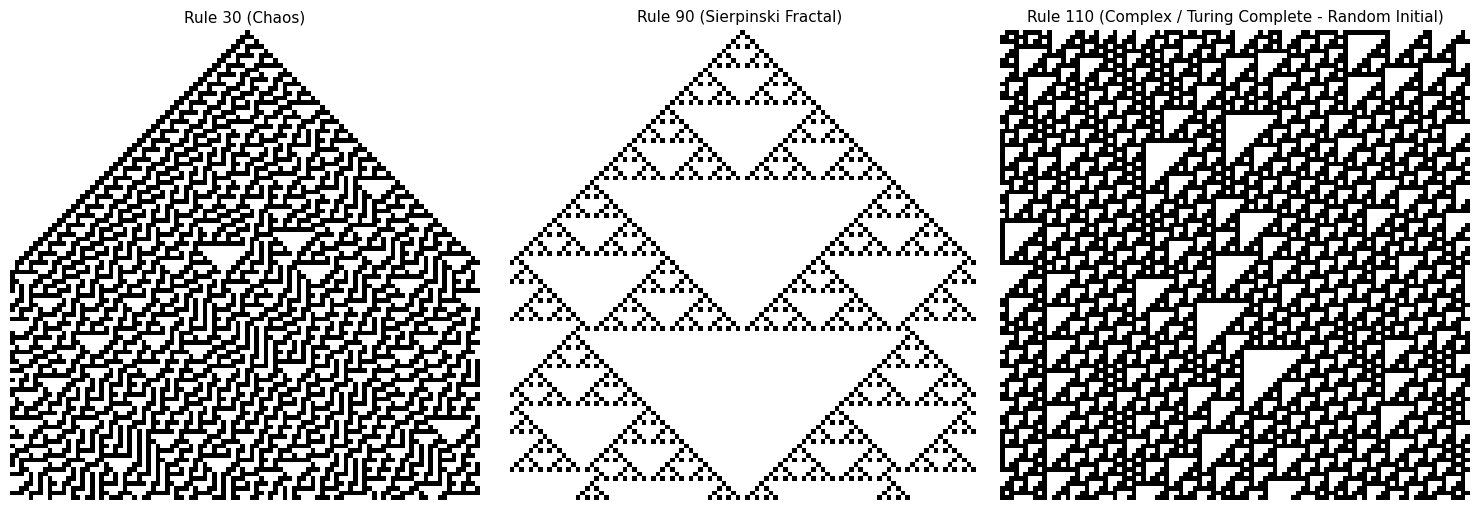

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_eca(rule_number: int, steps: int = 100, width: int = 100, initial_state: str = 'single') -> np.ndarray:
    """
    Simulates an Elementary Cellular Automaton (ECA).
    
    Parameters:
        rule_number: Wolfram rule number (0 to 255)
        steps: Number of time steps / rows (default 100)
        width: Number of spatial cells / columns (default 100)
        initial_state: 'single' (1 in the middle) or 'random'
    """
    # Convert rule number into an 8-bit lookup array
    rule_lookup = np.array([(rule_number >> i) & 1 for i in range(8)], dtype=int)
    
    # Initialize grid (steps x width)
    grid = np.zeros((steps, width), dtype=int)
    
    if initial_state == 'single':
        grid[0, width // 2] = 1
    elif initial_state == 'random':
        grid[0] = np.random.randint(0, 2, size=width)
        
    # Evolve spatio-temporal pattern across time steps
    for t in range(1, steps):
        # Neighborhood calculation
        left = np.roll(grid[t - 1], 1)      # Left neighbor (with periodic boundary)
        center = grid[t - 1]                # Center cell
        right = np.roll(grid[t - 1], -1)    # Right neighbor (with periodic boundary)
        
        # Binary index = (Left * 4) + (Center * 2) + (Right * 1)
        neighborhood_indices = (left << 2) | (center << 1) | right
        
        # Apply rule lookup
        grid[t] = rule_lookup[neighborhood_indices]
        
    return grid

# Examples & Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rules_to_plot = [
    (30, 'single', 'Rule 30 (Chaos)'),
    (90, 'single', 'Rule 90 (Sierpinski Fractal)'),
    (110, 'random', 'Rule 110 (Complex / Turing Complete - Random Initial)')
]

for ax, (rule, init_type, title) in zip(axes, rules_to_plot):
    grid = simulate_eca(rule_number=rule, steps=100, width=100, initial_state=init_type)
    ax.imshow(grid, cmap='binary', interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()